In [1]:
import numpy as np
import matplotlib.pyplot as plt
import string
import os

plt.rcParams.update(
    {
        "font.size": 11,  # base font size (tick labels)
        "axes.labelsize": 13,  # axis labels
        "axes.titlesize": 13,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "figure.dpi": 300,
    }
)

import jax.numpy as jnp
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_device", jax.devices("cpu")[0])

# Import your optimization and plotting utilities
from optimization_core import (
    scaled_spdc_jsa_chirped,
    penalty_norm_relaxation_box_grad_desc,
    load_results,
    to_complex,
)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
# --- Files to load ---
files = {
    "3D": "residuals_eigen_cond_chirped_3D.npz",
}

/home/gisell/miniconda3/envs/tensor_lo_optim/lib/python3.14/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/gisell/miniconda3/envs/tensor_lo_optim/lib/python3.14/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


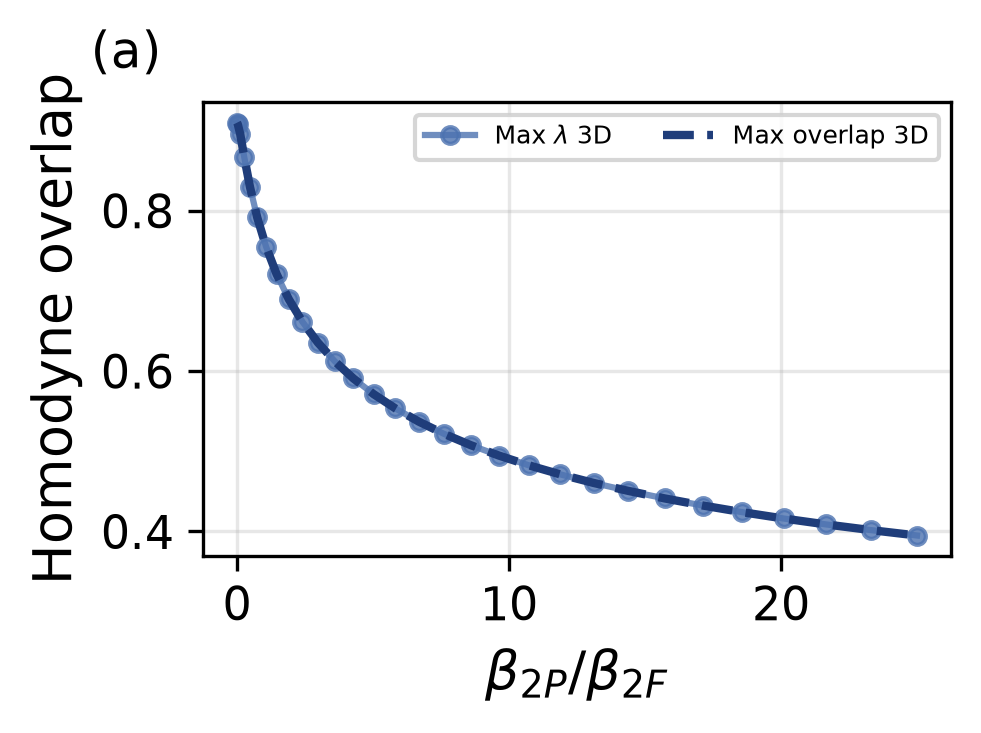

In [3]:
fig, ax = plt.subplots(figsize=(3.4, 2.6))

colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52"]
colors2 = [
    "#1f3d7a",  # dark navy
    "#b34700",  # dark orange-brown
    "#1a5e1a",  # dark green
    "#7a1a1a",  # dark red
]
index = 0

for label, filename in files.items():
    data = np.load(filename)
    taup = data["taup"]
    tauf = data["tauf"]
    residuals = data["residuals"]
    max_eigenvalues = data["max_eigenvalues"]
    overlaps = data["overlaps"]

    ax.plot(
        (taup**2 / tauf**2),
        max_eigenvalues,
        markersize=4,
        label=r"Max $\lambda$ " + label,
        marker="o",
        color=colors[index],
        alpha=0.8,
    )
    ax.plot(
        (taup**2 / tauf**2),
        overlaps,
        markersize=4,
        label=r"Max overlap " + label,
        linestyle="--",
        color=colors2[index],
        linewidth=2,
    )
    index += 1

ax.set_xlabel(r"$\beta_{2P}/\beta_{2F}$")
ax.set_ylabel("Homodyne overlap")
ax.legend(fontsize=6, ncol=2)
ax.grid(True, which="both", alpha=0.3)

ax.text(-0.15, 1.05, "(a)", transform=ax.transAxes, fontsize=12, va="bottom", ha="left")
plt.tight_layout()

plt.savefig(f"max_eigen_overlap_hopdc_chirped.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
(taup**2 / tauf**2)

array([ 0.        ,  0.02972652,  0.11890606,  0.26753864,  0.47562426,
        0.7431629 ,  1.07015458,  1.45659929,  1.90249703,  2.4078478 ,
        2.97265161,  3.59690844,  4.28061831,  5.02378121,  5.82639715,
        6.68846611,  7.60998811,  8.59096314,  9.6313912 , 10.73127229,
       11.89060642, 13.10939358, 14.38763377, 15.72532699, 17.12247325,
       18.57907253, 20.09512485, 21.6706302 , 23.30558859, 25.        ])

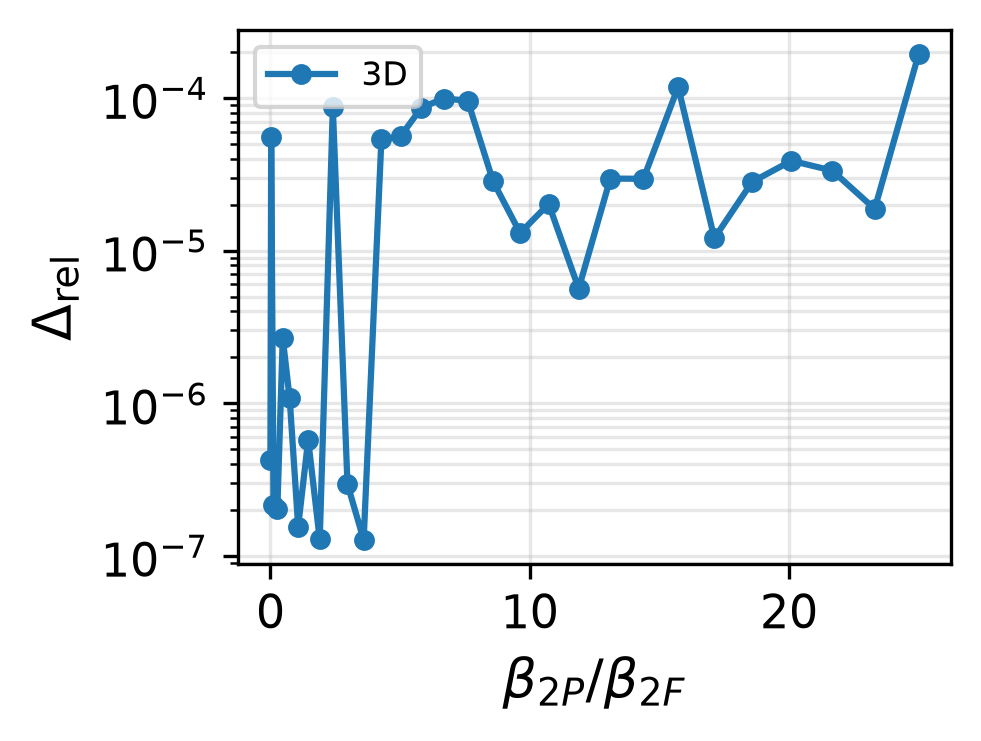

In [5]:
fig, ax = plt.subplots(figsize=(3.4, 2.6))

for label, filename in files.items():
    data = np.load(filename)
    taup = data["taup"]
    tauf = data["tauf"]
    residuals = data["residuals"]
    max_eigenvalues = data["max_eigenvalues"]
    overlaps = data["overlaps"]

    ax.semilogy(
        (taup**2 / tauf**2),
        jnp.abs(max_eigenvalues - overlaps),
        markersize=4,
        label=label,
        marker="o",
    )

ax.set_xlabel(r"$\beta_{2P}/\beta_{2F}$")

ax.set_ylabel(r"$\Delta_\text{rel}$")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
# plt.savefig(f'rel_residual_hopdc.pdf', dpi=300, bbox_inches='tight')

plt.show()

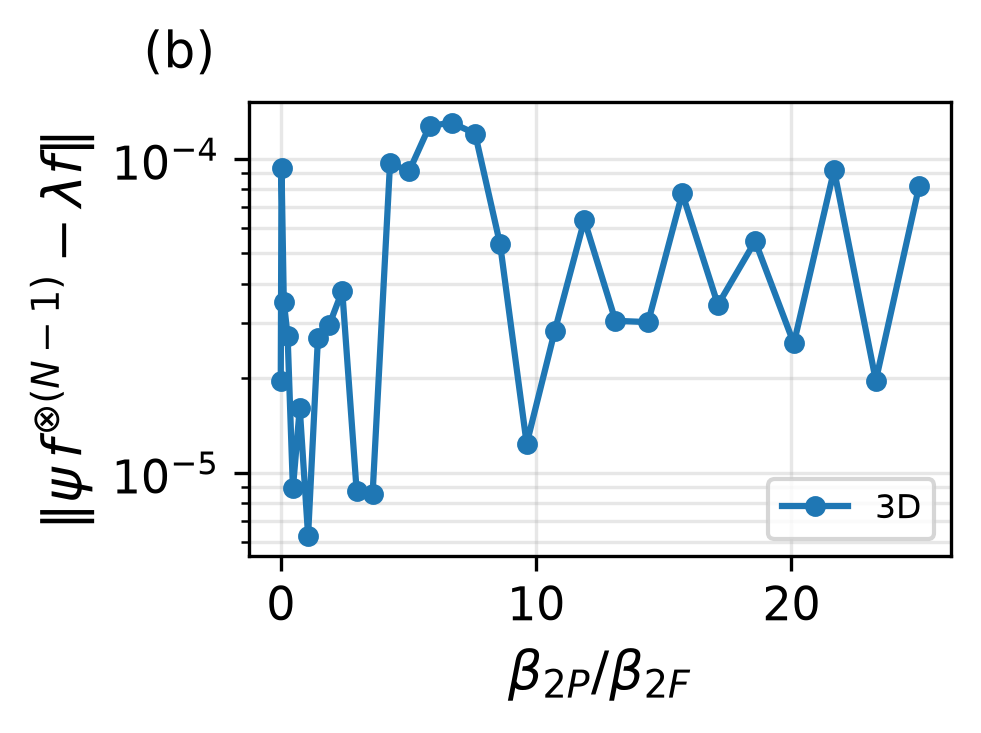

In [6]:
fig, ax = plt.subplots(figsize=(3.4, 2.6))

for label, filename in files.items():
    data = np.load(filename)
    taup = data["taup"]
    tauf = data["tauf"]
    residuals = data["residuals"]
    max_eigenvalues = data["max_eigenvalues"]
    overlaps = data["overlaps"]

    ax.semilogy((taup**2 / tauf**2), residuals, markersize=4, label=label, marker="o")

ax.set_xlabel(r"$\beta_{2P}/\beta_{2F}$")
ax.set_ylabel(r"$\|\psi\,f^{\otimes (N-1)} - \lambda f\|$")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.3)

ax.text(-0.15, 1.05, "(b)", transform=ax.transAxes, fontsize=12, va="bottom", ha="left")

plt.tight_layout()
plt.savefig(f"residual_eigen_cond_hopdc_chirped.pdf", dpi=300, bbox_inches="tight")

plt.show()